✅ Configuration loaded for English pipeline (v3.1).

📊 STEP 1: DESCRIPTIVE AUDIT (Raw Volume & Rate Shifts)
❓ WHY: Establishes the baseline descriptive statistics and raw shifts before modeling.
📈 WHAT: Provides the raw counts and proportions for the methodology section.

- ARTICLE VOLUME (Total Count) -
period                                        Post-MCC  Pre-MCC
Macro_Bucket                                                   
Agriculture And Rural Life                         265      831
Business, Financial Markets, And The Economy      2611     5715
Defense And National Security                     7477    17327
Education And Academia                             154        2
Electoral Politics And Election Campaigns        42822    41367
Environment And Climate                           1154     2574
Government Policy And Welfare Schemes            10627    22805
Health And Medicine                                 68      138
Infrastructure And Development Projects           3998

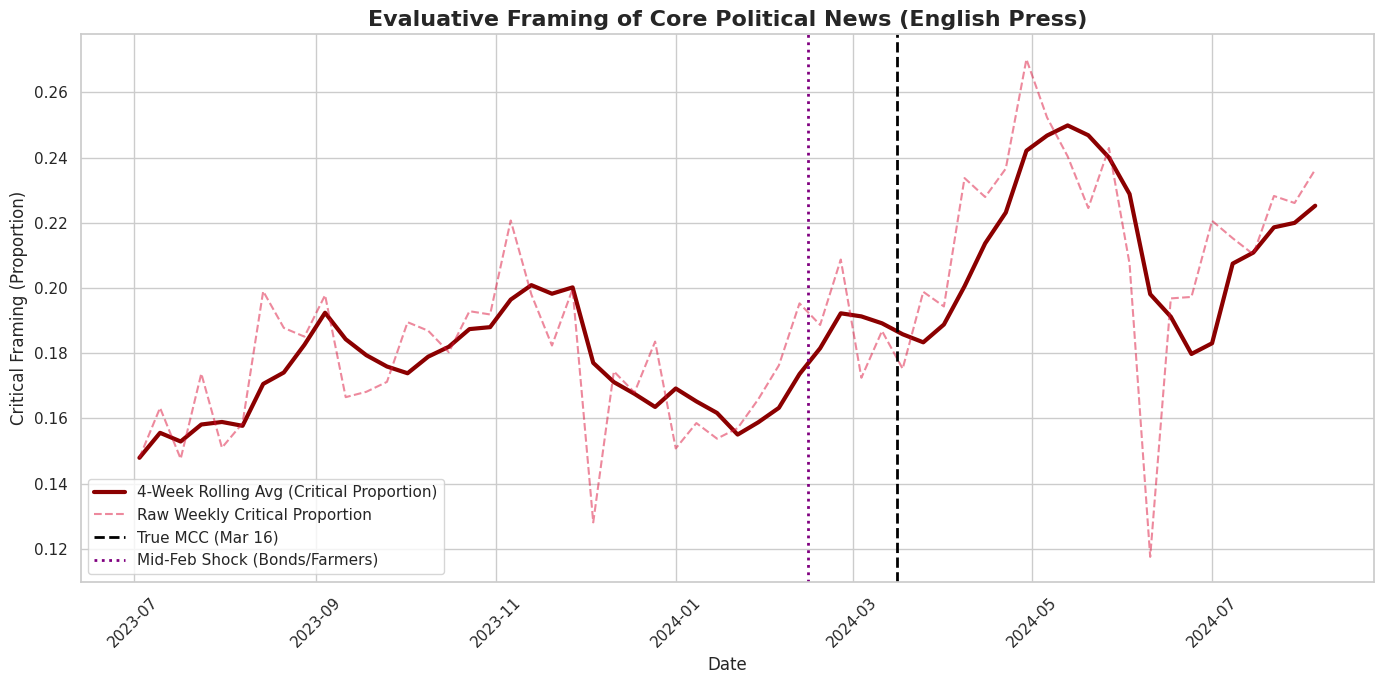

💾 Plot saved to /kaggle/working/Track_A_Money_Plot_English.png

📈 STEP 3: CORE LOCAL LINEAR ITS WITH CONFOUND CONTROLS (±12 Weeks)
❓ WHY: Estimates the causal effect of MCC, controlling for outlet fixed effects
   and specific confounding events (Ram Mandir, Budget, Mid-Feb Shock, Lists).
📈 WHAT: Provides the primary Level Shift (immediate shock) and Slope Change coefficients.
                                Parameter Estimates                                
                 Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------
time_t              0.0063     0.0008     7.6333     0.0000      0.0046      0.0079
post_mcc            0.0857     0.0722     1.1875     0.2371     -0.0570      0.2284
post_mcc_x_time    -0.0069     0.0041    -1.6904     0.0932     -0.0150      0.0012
ram_mandir_week    -0.0128     0.0026    -4.8407     0.0000     -0.0180     -0.0075
budget_week        -0.0102     0

In [20]:
# ==========================================
# BHARAT MEDIA PULSE: TRACK A ECONOMETRIC SUITE (v3.1)
# Interrupted Time Series (ITS) on Cascade NLI Outputs
# ==========================================
# CHANGES IN v3.1:
#   1. Step 2 now prints a numerical weekly table alongside the graph.
#   2. Step 7 thematic subsets now print explicit skip/error messages
#      instead of silently producing empty output.
#   3. All prior v3 improvements retained (widened bandwidth, merged
#      mid_feb_shock, magnitude-based placebo check).
# ==========================================

import subprocess, sys
def install_deps():
    pkgs = ["linearmodels", "pandas", "numpy", "matplotlib", "seaborn", "statsmodels", "scipy", "tabulate"]
    for p in pkgs:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])
install_deps()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. CONFIGURATION & KEY DATES
# ==========================================
LANGUAGE = "English"  # Change to "English" to run the English pipeline

if LANGUAGE == "English":
    MASTER_PATH = '/kaggle/input/notebooks/shivanguniyal/english-2024-nli/English_Master_Processed_Level1_2024.csv'
    PLOT_TITLE = 'Evaluative Framing of Core Political News (English Press)'
    OUT_PLOT = '/kaggle/working/Track_A_Money_Plot_English.png'
else:
    MASTER_PATH = '/kaggle/input/datasets/shivanguniyal/hindi-master-processed-level1-2024/Hindi_Master_Processed_Level1_2024.csv'
    PLOT_TITLE = 'Evaluative Framing of Core Political News (Hindi Press)'
    OUT_PLOT = '/kaggle/working/Track_A_Money_Plot_Hindi.png'

# Core Intervention
MCC_DATE = pd.to_datetime('2024-03-16')

# Confound Events
BUDGET_DATE = pd.to_datetime('2024-02-01')
MID_FEB_SHOCK_DATE = pd.to_datetime('2024-02-15')
BJP_LIST_DATE = pd.to_datetime('2024-03-02')
CONG_LIST_DATE = pd.to_datetime('2024-03-08')
RAM_MANDIR_DATE = pd.to_datetime('2024-01-22')

# WIDENED BANDWIDTH: ±12 weeks
BANDWIDTH_WEEKS = 12
START_DATE = MCC_DATE - pd.Timedelta(weeks=BANDWIDTH_WEEKS)
END_DATE = MCC_DATE + pd.Timedelta(weeks=BANDWIDTH_WEEKS)

# Thematic Buckets
THEMES = {
    'Electoral': 'Electoral Politics And Election Campaigns',
    'Judicial': 'Law, Crime, And The Justice System',
    'Welfare': 'Government Policy And Welfare Schemes',
    'Society': 'Society, Culture, And Religion',
    'Defense': 'Defense And National Security'
}

MAGNITUDE_IMPLAUSIBLE_THRESHOLD = 0.30

# ==========================================
# HELPER: CONFOUND DUMMY CONSTRUCTION
# ==========================================
def add_confound_dummies(panel_df, date_col='date'):
    d = panel_df[date_col]
    panel_df['ram_mandir_week'] = ((d >= '2024-01-22') & (d <= '2024-01-28')).astype(int)
    panel_df['budget_week'] = ((d >= '2024-01-29') & (d <= '2024-02-04')).astype(int)
    panel_df['mid_feb_shock'] = ((d >= '2024-02-12') & (d <= '2024-02-25')).astype(int)
    panel_df['bjp_list_week'] = ((d >= '2024-03-02') & (d <= '2024-03-08')).astype(int)
    panel_df['cong_list_week'] = ((d >= '2024-03-08') & (d <= '2024-03-14')).astype(int)
    return panel_df

CONFOUND_COLS = ['ram_mandir_week', 'budget_week', 'mid_feb_shock', 'bjp_list_week', 'cong_list_week']

# ==========================================
# HELPER: SAFE PANEL OLS WRAPPER
# ==========================================
def run_panel_its(panel, y_col, X_cols, entity_effects=True):
    panel = panel.copy()
    if not isinstance(panel.index, pd.MultiIndex):
        panel = panel.set_index(['newspaper', 'date'])

    valid_X = [c for c in X_cols if c in panel.columns and panel[c].nunique() > 1]
    if not valid_X:
        return None

    X = panel[valid_X]
    y = panel[y_col]

    mod = PanelOLS(y, X, entity_effects=entity_effects, drop_absorbed=True)
    res = mod.fit(cov_type='kernel', kernel='bartlett', bandwidth=3)
    return res

print(f"✅ Configuration loaded for {LANGUAGE} pipeline (v3.1).")

# ==========================================
# STEP 1: DESCRIPTIVE AUDIT
# ==========================================
print("\n" + "="*80)
print("📊 STEP 1: DESCRIPTIVE AUDIT (Raw Volume & Rate Shifts)")
print("="*80)
print("❓ WHY: Establishes the baseline descriptive statistics and raw shifts before modeling.")
print("📈 WHAT: Provides the raw counts and proportions for the methodology section.")

df = pd.read_csv(MASTER_PATH)
df['date'] = pd.to_datetime(df['date'])
df['is_critical'] = (df['final_label'].str.lower() == 'critical').astype(int)

df['period'] = np.where(df['date'] < MCC_DATE, 'Pre-MCC', 'Post-MCC')
audit = df.groupby(['Macro_Bucket', 'period']).agg(
    total_articles=('article_id', 'count'),
    critical_articles=('is_critical', 'sum')
).reset_index()
audit['critical_rate'] = audit['critical_articles'] / audit['total_articles']

vol_pivot = audit.pivot(index='Macro_Bucket', columns='period', values='total_articles').fillna(0)
rate_pivot = audit.pivot(index='Macro_Bucket', columns='period', values='critical_rate').fillna(0)

print("\n- ARTICLE VOLUME (Total Count) -")
print(vol_pivot.astype(int).to_string())
print("\n- CRITICAL RATE (Proportion Critical) -")
print(rate_pivot.round(3).to_string())

# ==========================================
# STEP 2: TIME-SERIES VISUALIZATION + NUMERICAL TABLE
# ==========================================
print("\n" + "="*80)
print("🎨 STEP 2: TIME-SERIES VISUALIZATION (The 'Money Plot')")
print("="*80)
print("❓ WHY: Visual inspection of trends, shocks, and structural breaks.")
print("📈 WHAT: The primary figure for the paper showing the macro-level framing trajectory.")

panel_all = df.groupby(['newspaper', pd.Grouper(key='date', freq='W-MON')]).agg(
    total_articles=('article_id', 'count'),
    n_critical=('is_critical', 'sum')
).reset_index()
panel_all['critical_rate'] = panel_all['n_critical'] / panel_all['total_articles']
panel_all = panel_all[panel_all['total_articles'] >= 5].dropna().copy()

macro_trend = panel_all.groupby('date').agg(
    total_articles=('total_articles', 'sum'),
    n_critical=('n_critical', 'sum'),
    hard_rate=('critical_rate', 'mean')
).reset_index()
macro_trend['roll_hard'] = macro_trend['hard_rate'].rolling(4, min_periods=1).mean()

# --- NUMERICAL OUTPUT ---
print("\n" + "="*80)
print("📊 NUMERICAL OUTPUT: WEEKLY MACRO TRENDS")
print("="*80)
macro_display = macro_trend.copy()
macro_display['date_str'] = macro_display['date'].dt.strftime('%Y-%m-%d')
macro_display['critical_rate'] = macro_display['hard_rate'].round(3)
macro_display['roll_4wk'] = macro_display['roll_hard'].round(3)
print(macro_display[['date_str', 'total_articles', 'n_critical', 'critical_rate', 'roll_4wk']].to_string(index=False))
print("="*80)

# --- GRAPH ---
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
plt.plot(macro_trend['date'], macro_trend['roll_hard'],
         label='4-Week Rolling Avg (Critical Proportion)', color='darkred', linewidth=3)
plt.plot(macro_trend['date'], macro_trend['hard_rate'],
         label='Raw Weekly Critical Proportion', color='crimson', linewidth=1.5,
         linestyle='--', alpha=0.5)

plt.axvline(x=MCC_DATE, color='black', linestyle='--', linewidth=2, label='True MCC (Mar 16)')
plt.axvline(x=MID_FEB_SHOCK_DATE, color='purple', linestyle=':', linewidth=2,
            label='Mid-Feb Shock (Bonds/Farmers)')

plt.title(PLOT_TITLE, fontsize=16, fontweight='bold')
plt.ylabel('Critical Framing (Proportion)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='lower left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT_PLOT, dpi=300)
plt.show()
print(f"💾 Plot saved to {OUT_PLOT}")

# ==========================================
# STEP 3: CORE LOCAL LINEAR ITS (±12 Weeks)
# ==========================================
print("\n" + "="*80)
print("📈 STEP 3: CORE LOCAL LINEAR ITS WITH CONFOUND CONTROLS (±12 Weeks)")
print("="*80)
print("❓ WHY: Estimates the causal effect of MCC, controlling for outlet fixed effects")
print("   and specific confounding events (Ram Mandir, Budget, Mid-Feb Shock, Lists).")
print("📈 WHAT: Provides the primary Level Shift (immediate shock) and Slope Change coefficients.")

df_bw = df[(df['date'] >= START_DATE) & (df['date'] <= END_DATE)].copy()
panel_bw = df_bw.groupby(['newspaper', pd.Grouper(key='date', freq='W-MON')]).agg(
    total_articles=('article_id', 'count'), n_critical=('is_critical', 'sum')
).reset_index()
panel_bw['critical_rate'] = panel_bw['n_critical'] / panel_bw['total_articles']
panel_bw = panel_bw[panel_bw['total_articles'] >= 5].dropna().copy()

panel_bw['time_t'] = (panel_bw['date'] - START_DATE).dt.days / 7
panel_bw['post_mcc'] = (panel_bw['date'] >= MCC_DATE).astype(int)
panel_bw['post_mcc_x_time'] = panel_bw['post_mcc'] * panel_bw['time_t']
panel_bw = add_confound_dummies(panel_bw)

X_cols_main = ['time_t', 'post_mcc', 'post_mcc_x_time'] + CONFOUND_COLS
res_main = run_panel_its(panel_bw, 'critical_rate', X_cols_main)

if res_main:
    print(res_main.summary.tables[1])
    mcc_jump = res_main.params.get('post_mcc', np.nan)
    mcc_slope = res_main.params.get('post_mcc_x_time', np.nan)
    print(f"\n💡 INTERPRETATION: MCC Immediate Jump: {mcc_jump:+.4f} "
          f"(p={res_main.pvalues.get('post_mcc', 1):.4f}) | "
          f"Slope Change: {mcc_slope:+.4f} "
          f"(p={res_main.pvalues.get('post_mcc_x_time', 1):.4f})")
else:
    print("⚠️ Main ITS model returned None (check data volume).")

# ==========================================
# STEP 4: REFERENCE-PERIOD DIAGNOSTIC
# ==========================================
print("\n" + "="*80)
print("🔍 STEP 4: REFERENCE-PERIOD DIAGNOSTIC")
print("="*80)
print("❓ WHY: Ensures the omitted baseline (reference group) is sufficiently large.")
print("📈 WHAT: Proves to reviewers that the baseline isn't too small to be meaningful.")

confound_cols_present = [c for c in panel_bw.columns if c in CONFOUND_COLS]
total_weeks = panel_bw['date'].nunique()

pre_mcc_mask = panel_bw['date'] < MCC_DATE
if confound_cols_present:
    no_confound_mask = panel_bw[confound_cols_present].sum(axis=1) == 0
    reference_mask = pre_mcc_mask & no_confound_mask
else:
    reference_mask = pre_mcc_mask

reference_weeks = panel_bw[reference_mask]['date'].nunique()
ratio = reference_weeks / total_weeks if total_weeks > 0 else 0

print(f"Total unique weeks in ±{BANDWIDTH_WEEKS}-week window: {total_weeks}")
print(f"Unique Omitted Baseline (Reference) weeks: {reference_weeks}")
print(f"Reference / Total Ratio: {ratio:.2%}")
if ratio < 0.15:
    print("⚠️ WARNING: Reference period is very small. Baseline identification might be weak.")
else:
    print("✅ Baseline identification looks healthy.")

# ==========================================
# STEP 5: IN-WINDOW PLACEBO SWEEP
# ==========================================
print("\n" + "="*70)
print("🧪 STEP 5: IN-WINDOW PLACEBO SWEEP (Falsification)")
print("="*70)
print("❓ WHY: Sweeps multiple candidate cutoffs and flags BOTH numerically degenerate")
print("   fits AND implausibly large coefficients.")
print("📈 WHAT: A robust Pass/Fail verdict for the parallel-trends assumption.")

def run_placebo_at(df_full, cutoff_date, start_date, mcc_date):
    df_pre = df_full[(df_full['date'] >= start_date) & (df_full['date'] < mcc_date)].copy()
    panel_pre = df_pre.groupby(['newspaper', pd.Grouper(key='date', freq='W-MON')]).agg(
        total_articles=('article_id', 'count'), n_critical=('is_critical', 'sum')
    ).reset_index()
    panel_pre['critical_rate'] = panel_pre['n_critical'] / panel_pre['total_articles']
    panel_pre = panel_pre[panel_pre['total_articles'] >= 5].dropna().copy()
    if panel_pre.empty:
        return None

    panel_pre['time_t'] = (panel_pre['date'] - start_date).dt.days / 7
    panel_pre = add_confound_dummies(panel_pre)

    panel_pre['post_placebo'] = (panel_pre['date'] >= cutoff_date).astype(int)
    panel_pre['post_placebo_x_time'] = panel_pre['post_placebo'] * panel_pre['time_t']

    X_cols = ['time_t', 'post_placebo', 'post_placebo_x_time'] + CONFOUND_COLS

    try:
        res = run_panel_its(panel_pre, 'critical_rate', X_cols)
    except ValueError:
        return {
            'cutoff': cutoff_date.date(), 'weeks_before_mcc': int((mcc_date - cutoff_date).days / 7),
            'coeff': np.nan, 'pval': np.nan, 'se': np.nan,
            'degenerate_se': True, 'implausible_magnitude': None,
        }
    if res is None:
        return None

    coeff = res.params.get('post_placebo', np.nan)
    se = res.std_errors.get('post_placebo', np.nan)
    pval = res.pvalues.get('post_placebo', np.nan)

    degenerate_se = (not np.isnan(se)) and (se < 1e-6)
    implausible_magnitude = (not np.isnan(coeff)) and (abs(coeff) > MAGNITUDE_IMPLAUSIBLE_THRESHOLD)

    return {
        'cutoff': cutoff_date.date(), 'weeks_before_mcc': int((mcc_date - cutoff_date).days / 7),
        'coeff': coeff, 'pval': pval, 'se': se,
        'degenerate_se': degenerate_se, 'implausible_magnitude': implausible_magnitude,
    }

sweep_results = []
for weeks_before in [4, 6, 8, 10]:
    cutoff = MCC_DATE - pd.Timedelta(weeks=weeks_before)
    r = run_placebo_at(df, cutoff, START_DATE, MCC_DATE)
    if r:
        sweep_results.append(r)

df_sweep = pd.DataFrame(sweep_results)
print("\n--- Placebo Sweep Results ---")
print(df_sweep.to_string(index=False))

if not df_sweep.empty:
    df_sweep['untrustworthy'] = df_sweep['degenerate_se'].fillna(False) | df_sweep['implausible_magnitude'].fillna(False)
    clean = df_sweep[~df_sweep['untrustworthy']]

    if len(clean) == 0:
        print("\n⚠️ Every candidate cutoff was degenerate or implausible -- the confound "
              "windows are too dense in this bandwidth to run a clean placebo test.")
    else:
        n_significant = (clean['pval'] < 0.05).sum()
        print(f"\n{n_significant}/{len(clean)} trustworthy placebo cutoffs show a significant break (p<0.05).")
        if n_significant == 0:
            print("✅ PASS: No trustworthy placebo cutoff shows a significant break.")
        elif n_significant < len(clean) / 2:
            print("⚠️ MIXED: Some but not most placebo cutoffs are significant.")
        else:
            print("⚠️ FAIL: Most trustworthy placebo cutoffs show a significant break.")

# ==========================================
# STEP 6: BANDWIDTH SENSITIVITY ANALYSIS
# ==========================================
print("\n" + "="*80)
print("📏 STEP 6: BANDWIDTH SENSITIVITY ANALYSIS")
print("="*80)
print("❓ WHY: Tests the robustness of the findings to the choice of temporal window.")
print("📈 WHAT: Proves the effect isn't an artifact of arbitrarily picking ±12 weeks.")

results_bw = []
for bw in [10, 12, 14]:
    start = MCC_DATE - pd.Timedelta(weeks=bw)
    end = MCC_DATE + pd.Timedelta(weeks=bw)
    df_temp = df[(df['date'] >= start) & (df['date'] <= end)].copy()
    p_temp = df_temp.groupby(['newspaper', pd.Grouper(key='date', freq='W-MON')]).agg(
        total=('article_id', 'count'), n_crit=('is_critical', 'sum')
    ).reset_index()
    p_temp['critical_rate'] = p_temp['n_crit'] / p_temp['total']
    p_temp = p_temp[p_temp['total'] >= 5].dropna().copy()

    if p_temp.empty or p_temp['newspaper'].nunique() < 2:
        continue

    p_temp['time_t'] = (p_temp['date'] - start).dt.days / 7
    p_temp['post_mcc'] = (p_temp['date'] >= MCC_DATE).astype(int)
    p_temp['post_mcc_x_time'] = p_temp['post_mcc'] * p_temp['time_t']
    p_temp = add_confound_dummies(p_temp)

    X_cols_bw = ['time_t', 'post_mcc', 'post_mcc_x_time'] + CONFOUND_COLS
    res_temp = run_panel_its(p_temp, 'critical_rate', X_cols_bw)
    if res_temp:
        results_bw.append({
            'Bandwidth': f'±{bw} Weeks',
            'Level Shift (β)': f"{res_temp.params.get('post_mcc', np.nan):+.4f}",
            'Level p-val': f"{res_temp.pvalues.get('post_mcc', 1):.3f}",
            'Slope Shift (β)': f"{res_temp.params.get('post_mcc_x_time', np.nan):+.4f}",
            'Slope p-val': f"{res_temp.pvalues.get('post_mcc_x_time', 1):.3f}"
        })

if results_bw:
    print(tabulate(pd.DataFrame(results_bw), headers="keys", tablefmt="pretty"))
else:
    print("⚠️ No bandwidth models returned results.")

# ==========================================
# STEP 7: THEMATIC SUBSET ITS (FIXED: no more silent failures)
# ==========================================
print("\n" + "="*70)
print("📂 STEP 7: THEMATIC SUBSET ITS (Displacement & Spillover)")
print("="*70)
print("❓ WHY: Understands *which* topics are driving the shift.")
print("📈 WHAT: Isolates the exact thematic buckets where displacement is occurring.\n")

for theme_name, bucket_name in THEMES.items():
    print(f"\n--- SUBSET: {theme_name.upper()} ---")

    df_sub = df[df['Macro_Bucket'] == bucket_name].copy()

    if df_sub.empty:
        print(f"⚠️ SKIPPED: No articles found for bucket '{bucket_name}'.")
        continue

    print(f"  Articles found: {len(df_sub):,}")

    panel_sub = df_sub.groupby(['newspaper', pd.Grouper(key='date', freq='W-MON')]).agg(
        total_articles=('article_id', 'count'),
        n_critical=('is_critical', 'sum')
    ).reset_index()

    panel_sub['critical_rate'] = panel_sub['n_critical'] / panel_sub['total_articles']
    panel_sub = panel_sub[panel_sub['total_articles'] >= 3].dropna(subset=['critical_rate']).copy()

    n_newspapers = panel_sub['newspaper'].nunique()
    n_weeks = panel_sub['date'].nunique()
    print(f"  Weekly panel rows: {len(panel_sub)} | Newspapers: {n_newspapers} | Weeks: {n_weeks}")

    if panel_sub.empty:
        print(f"⚠️ SKIPPED: Panel is empty after filtering (min 3 articles/week).")
        continue

    if n_newspapers < 2:
        print(f"⚠️ SKIPPED: Only {n_newspapers} newspaper(s) -- need >= 2 for entity fixed effects.")
        continue

    # Feature Engineering
    panel_sub['time_t'] = (panel_sub['date'] - panel_sub['date'].min()).dt.days / 7
    panel_sub['post_mcc'] = (panel_sub['date'] >= MCC_DATE).astype(int)
    panel_sub['post_mcc_x_time'] = panel_sub['post_mcc'] * panel_sub['time_t']
    panel_sub = add_confound_dummies(panel_sub)
    panel_sub = panel_sub.set_index(['newspaper', 'date'])

    X_cols = ['time_t', 'post_mcc', 'post_mcc_x_time'] + CONFOUND_COLS
    valid_X_cols = [c for c in X_cols if c in panel_sub.columns and panel_sub[c].nunique() > 1]

    dropped_cols = [c for c in X_cols if c not in valid_X_cols]
    if dropped_cols:
        print(f"  ℹ️ Dropped zero-variance columns: {dropped_cols}")

    if 'post_mcc' not in valid_X_cols:
        print(f"⚠️ SKIPPED: 'post_mcc' has zero variance (all pre- or all post-MCC in this subset).")
        continue

    X = panel_sub[valid_X_cols]
    y = panel_sub['critical_rate']

    try:
        mod = PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
        res_sub = mod.fit(cov_type='kernel', kernel='bartlett', bandwidth=3)

        try:
            print(res_sub.summary.tables[1])
        except np.linalg.LinAlgError:
            print("⚠️ Covariance matrix is singular. Displaying raw parameters instead:")
            params_df = pd.DataFrame({
                'Parameter': res_sub.params.index,
                'Coeff': res_sub.params.values,
                'Std. Err.': res_sub.std_errors.values,
                'P-value': res_sub.pvalues.values
            })
            print(params_df.to_string(index=False))

    except Exception as e:
        print(f"❌ Model FAILED to fit: {type(e).__name__}: {e}")

# ==========================================
# STEP 8: AGENDA COMPOSITION SHIFT
# ==========================================
print("\n" + "="*80)
print("📊 STEP 8: AGENDA COMPOSITION SHIFT (The Denominator Test)")
print("="*80)
print("❓ WHY: Checks if the *volume* of topics shifted (displacement), not just framing.")
print("📈 WHAT: Proves whether the media actively crowded out non-electoral news.")

weekly_bucket_vol = df.groupby([pd.Grouper(key='date', freq='W-MON'), 'Macro_Bucket']).size().reset_index(name='count')
weekly_total_vol = df.groupby([pd.Grouper(key='date', freq='W-MON')]).size().reset_index(name='total_count')
weekly_bucket_vol = weekly_bucket_vol.merge(weekly_total_vol, on='date')
weekly_bucket_vol['share'] = weekly_bucket_vol['count'] / weekly_bucket_vol['total_count']

comp_df = weekly_bucket_vol[weekly_bucket_vol['Macro_Bucket'].isin(THEMES.values())].copy()
comp_df['period'] = np.where(comp_df['date'] < MCC_DATE, 'Pre-MCC', 'Post-MCC')

agenda_shift = comp_df.groupby(['Macro_Bucket', 'period'])['share'].mean().unstack()
if 'Pre-MCC' in agenda_shift.columns and 'Post-MCC' in agenda_shift.columns:
    agenda_shift['Shift (pp)'] = (agenda_shift['Post-MCC'] - agenda_shift['Pre-MCC'])
    print("\n- AVERAGE WEEKLY AGENDA SHARE (%) -")
    print((agenda_shift * 100).round(2).to_string())

# ==========================================
# STEP 9: COMPLEMENT SET ITS
# ==========================================
print("\n" + "="*80)
print("🔄 STEP 9: COMPLEMENT SET ITS (Non-Electoral Spillover)")
print("="*80)
print("❓ WHY: Isolates whether the effect is purely electoral or spills over.")
print("📈 WHAT: Proves whether MCC is localized to campaigns or systemic.")

df_comp = df[df['Macro_Bucket'] != 'Electoral Politics And Election Campaigns'].copy()
p_comp = df_comp.groupby(['newspaper', pd.Grouper(key='date', freq='W-MON')]).agg(
    total=('article_id', 'count'), n_crit=('is_critical', 'sum')
).reset_index()
p_comp['critical_rate'] = p_comp['n_crit'] / p_comp['total']
p_comp = p_comp[p_comp['total'] >= 5].dropna().copy()

if len(p_comp) > 0 and p_comp['newspaper'].nunique() >= 2:
    p_comp['time_t'] = (p_comp['date'] - START_DATE).dt.days / 7
    p_comp['post_mcc'] = (p_comp['date'] >= MCC_DATE).astype(int)
    p_comp['post_mcc_x_time'] = p_comp['post_mcc'] * p_comp['time_t']
    p_comp = add_confound_dummies(p_comp)

    X_cols_comp = ['time_t', 'post_mcc', 'post_mcc_x_time'] + CONFOUND_COLS
    res_comp = run_panel_its(p_comp, 'critical_rate', X_cols_comp)
    if res_comp:
        print(res_comp.summary.tables[1])
    else:
        print("⚠️ Complement ITS model returned None.")
else:
    print("⚠️ Insufficient data for Complement Set ITS.")

print("\n" + "="*80)
print("✅ TRACK A ECONOMETRIC SUITE (v3.1) COMPLETE.")
print("="*80)